# Advanced Big Data and Data Mining – Deliverable 2

**Student:** Sandesh Pokharel  
**Course:** MSCS-634 – Advanced Big Data and Data Mining  
**Instructor:** Dr. Satish Penmatsa
**Assignment:** Deliverable 2 – Regression Modeling & Performance Evaluation  
**Date:** 07/27/2025

---

This notebook is the second deliverable for the course **Advanced Big Data and Data Mining (MSCS-634)**. It builds on Deliverable 1, where we performed data collection, cleaning, and exploratory data analysis (EDA) on the UCI Heart Disease dataset.

# 🏗️ Deliverable 2 – Regression Modeling & Performance Evaluation

In this deliverable, we will build and evaluate regression models using the cleaned **UCI Heart Disease dataset** prepared in Deliverable 1. 

## Objectives:
- Perform **feature engineering** to improve the dataset for modeling.
- Build at least **two regression models** (e.g., Linear Regression and Ridge/Lasso).
- Evaluate models using metrics:
  - R² (coefficient of determination)
  - MSE (Mean Squared Error)
  - RMSE (Root Mean Squared Error)
- Use **cross-validation** to check generalization to unseen data.
- Compare the performance of the models and extract meaningful insights.

This notebook follows a structured approach:
1. Each step is first explained in markdown.
2. Then the corresponding code is presented and run.
3. Finally, the results are analyzed directly below the code/visualizations.

## 📂 Load Cleaned Dataset

We cleaned the dataset extensively in **Deliverable 1** (handled missing values, binary conversions, dropped low-quality columns, etc.). 

Here, we directly load the cleaned dataset `cleaned_heart_disease.csv` to start regression modeling without repeating the cleaning steps.

In [1]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("cleaned_heart_disease.csv")

# Display first 5 rows
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1,63,1,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,fixed defect,0
1,2,67,1,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,normal,2
2,3,67,1,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,reversable defect,1
3,4,37,1,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,normal,0
4,5,41,0,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,normal,0


## 🛠️ Feature Engineering

Before building regression models, we need to prepare the dataset:

1. **Binary Target:** Convert the target column `num` into binary values (1 = presence of heart disease, 0 = absence). In Deliverable 1, values greater than 0 indicated heart disease; we will keep the same rule.
2. **Drop Irrelevant Columns:** Remove columns like `id` and `dataset` which do not contribute to modeling.
3. **Encode Categorical Features:** Apply one-hot encoding to categorical columns (`cp`, `restecg`, `slope`, `thal`) so that they can be used in regression models.

In [2]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Binary target
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# 2. Drop irrelevant columns
df = df.drop(columns=['id', 'dataset'])

# 3. One-hot encode categorical variables
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Show the first 5 rows of engineered dataset
df.head()

,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,num,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,1,145.0,233.0,1.0,150.0,0.0,2.3,0,False,False,True,False,False,False,False,False,False
1,67,1,160.0,286.0,0.0,108.0,1.0,1.5,1,False,False,False,False,False,True,False,True,False
2,67,1,120.0,229.0,0.0,129.0,1.0,2.6,1,False,False,False,False,False,True,False,False,True
3,37,1,130.0,250.0,0.0,187.0,0.0,3.5,0,False,True,False,True,False,False,False,True,False
4,41,0,130.0,204.0,0.0,172.0,0.0,1.4,0,True,False,False,False,False,False,True,True,False


## ✂️ Train-Test Split

To evaluate our regression models, we split the dataset into:
- **Training Set (80%)**: Used to train the models.
- **Testing Set (20%)**: Used to evaluate performance on unseen data.

We also separate the target variable (`num`) from the features (all other columns).

In [3]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['num'])
y = df['num']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Show shapes of splits
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((736, 17), (184, 17), (736,), (184,))

## 📈 Model 1 – Logistic Regression

We will train a **Logistic Regression** model as our baseline classifier.  
- Logistic Regression is widely used for binary classification tasks and provides interpretable coefficients for each feature.  
- After training, we will evaluate it using **R², MSE, and RMSE** and compare it with other models later.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train logistic regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Predictions on test set
y_pred_log = log_reg.predict(X_test)

# Metrics
r2_log = r2_score(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

print(f"R²: {r2_log:.4f}")
print(f"MSE: {mse_log:.4f}")
print(f"RMSE: {rmse_log:.4f}")

R²: 0.3840
MSE: 0.1522
RMSE: 0.3901


/Users/mac/Sandesh_Cumberlands_Assignments/Advanced_Big_Data_And_Data_Mining/MSCS-634-Project/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 🔎 Analysis – Logistic Regression

- **R² Score:** 0.3840  
  This means the model explains about **38% of the variance** in the target variable. This is moderate but not ideal for predictive performance.
  
- **MSE:** 0.1522  
- **RMSE:** 0.3901  
  These error metrics are on a scale of 0–1 (since the target is binary). Lower values are better, and these suggest room for improvement.

**Next Steps:**  
We will try other models (e.g., Ridge or Lasso regression) to see if we can improve performance and reduce errors.

⚠️ *Note: A convergence warning appeared.* We can ignore it for now, but scaling features or increasing `max_iter` could address it in a more advanced version.

### ⚖️ Feature Scaling

We will scale the features using **StandardScaler** so that each feature has mean = 0 and standard deviation = 1.  
This helps models like Logistic Regression converge faster and perform better.

In [5]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Train logistic regression with scaled data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions on scaled test set
y_pred_log = log_reg.predict(X_test_scaled)

# Metrics remain the same
r2_log = r2_score(y_test, y_pred_log)
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)

print(f"R²: {r2_log:.4f}")
print(f"MSE: {mse_log:.4f}")
print(f"RMSE: {rmse_log:.4f}")

R²: 0.3400
MSE: 0.1630
RMSE: 0.4038


## 📊 Model 2 – Ridge Regression

Ridge Regression adds **L2 regularization**, which penalizes large coefficients and helps prevent overfitting.  
We will train Ridge Regression using the scaled features and evaluate it using the same metrics (R², MSE, RMSE).

In [7]:
from sklearn.linear_model import Ridge

# Initialize and train Ridge Regression
ridge_reg = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge_reg.predict(X_test_scaled)

# Metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print(f"R²: {r2_ridge:.4f}")
print(f"MSE: {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")

R²: 0.5019
MSE: 0.1231
RMSE: 0.3508


### 🔎 Analysis – Ridge Regression

- **R² Score:** 0.5019  
  Ridge Regression explains about **50% of the variance** in the target variable. This is a **notable improvement** over Logistic Regression (38%).  

- **MSE:** 0.1231  
- **RMSE:** 0.3508  
  Both error metrics are lower than those from Logistic Regression, indicating better predictions.

**Key Takeaways:**
- Regularization (L2) in Ridge Regression likely reduced model complexity and improved generalization.
- This model is performing **significantly better** and may be the stronger candidate for future modeling.

Next, we will perform **cross-validation** to confirm how well Ridge Regression generalizes to unseen data.

## 📌 Model 3 – Lasso Regression

Lasso Regression adds **L1 regularization**, which can shrink some coefficients to zero.  
This helps with **feature selection** and can improve model interpretability.  
We will train Lasso Regression on the scaled features and evaluate it using the same metrics (R², MSE, RMSE).

In [8]:
from sklearn.linear_model import Lasso

# Initialize and train Lasso Regression
lasso_reg = Lasso(alpha=0.01)  # alpha is the regularization strength
lasso_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso_reg.predict(X_test_scaled)

# Metrics
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print(f"R²: {r2_lasso:.4f}")
print(f"MSE: {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")

R²: 0.4944
MSE: 0.1249
RMSE: 0.3534


### 🔎 Analysis – Lasso Regression

- **R² Score:** 0.4944  
  Lasso Regression explains about **49% of the variance** in the target variable. This is slightly lower than Ridge Regression (50%) but still significantly better than Logistic Regression (34%).  

- **MSE:** 0.1249  
- **RMSE:** 0.3534  
  The error metrics are very close to Ridge Regression, showing that both regularized models perform similarly.

**Key Takeaways:**
- Lasso Regression provides competitive performance compared to Ridge Regression.
- Unlike Ridge, Lasso can shrink some coefficients to zero, which helps in **feature selection** and may lead to a simpler model.

## 🔄 Cross-Validation – Logistic Regression

To assess the generalization performance of **Logistic Regression**, we perform **5-fold cross-validation**.  
This technique splits the training data into 5 folds:
- 4 folds are used for training and 1 fold for validation, repeated 5 times.
- We then calculate the mean and standard deviation of the cross-validation scores.

In [9]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Logistic Regression (using scaled features)
cv_scores_log = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='r2')

print("Cross-Validation R² scores:", cv_scores_log)
print(f"Mean R²: {cv_scores_log.mean():.4f}")
print(f"Standard Deviation: {cv_scores_log.std():.4f}")

Cross-Validation R² scores: [0.28898744 0.14502814 0.0375982  0.20258137 0.28507295]
Mean R²: 0.1919
Standard Deviation: 0.0941


In [10]:
### 🔎 Analysis – Logistic Regression (Cross-Validation)

- **Mean R² Score:** 0.1919  
  Logistic Regression explains only about **19% of the variance** on average during cross-validation.  
- **Standard Deviation:** 0.0941  
  The relatively high standard deviation shows some variability in performance across folds.

**Key Takeaways:**
- Logistic Regression has limited generalization ability compared to its test-set R² (0.34).  
- This further confirms the need for more robust models like Ridge or Lasso.

SyntaxError: invalid character '²' (U+00B2) (1961789187.py, line 3)

### 🔎 Analysis – Logistic Regression (Cross-Validation)

- **Mean R² Score:** 0.1919  
  Logistic Regression explains only about **19% of the variance** on average during cross-validation.  
- **Standard Deviation:** 0.0941  
  The relatively high standard deviation shows some variability in performance across folds.

**Key Takeaways:**
- Logistic Regression has limited generalization ability compared to its test-set R² (0.34).  
- This further confirms the need for more robust models like Ridge or Lasso.

## 🔄 Cross-Validation – Ridge Regression

We now perform **5-fold cross-validation** for **Ridge Regression** to evaluate its generalization performance.  
This will help us see how consistent Ridge Regression is across different subsets of the training data.

In [11]:
# Cross-validation for Ridge Regression (using scaled features)
cv_scores_ridge = cross_val_score(ridge_reg, X_train_scaled, y_train, cv=5, scoring='r2')

print("Cross-Validation R² scores:", cv_scores_ridge)
print(f"Mean R²: {cv_scores_ridge.mean():.4f}")
print(f"Standard Deviation: {cv_scores_ridge.std():.4f}")

Cross-Validation R² scores: [0.48426174 0.45187606 0.33207796 0.4031617  0.42956044]
Mean R²: 0.4202
Standard Deviation: 0.0515


### 🔎 Analysis – Ridge Regression (Cross-Validation)

- **Mean R² Score:** 0.4202  
  Ridge Regression explains about **42% of the variance** on average during cross-validation, which is **substantially better** than Logistic Regression (19%).  

- **Standard Deviation:** 0.0515  
  The low standard deviation indicates that Ridge Regression is **consistent across folds** and not overly sensitive to data splits.

**Key Takeaways:**
- Ridge Regression generalizes far better than Logistic Regression.  
- Its stability across folds makes it a strong candidate for the best-performing model so far.

## 🔄 Cross-Validation – Lasso Regression

Finally, we perform **5-fold cross-validation** for **Lasso Regression** to evaluate its generalization performance.  
This will also help us compare it directly with Logistic and Ridge Regression.

In [12]:
# Cross-validation for Lasso Regression (using scaled features)
cv_scores_lasso = cross_val_score(lasso_reg, X_train_scaled, y_train, cv=5, scoring='r2')

print("Cross-Validation R² scores:", cv_scores_lasso)
print(f"Mean R²: {cv_scores_lasso.mean():.4f}")
print(f"Standard Deviation: {cv_scores_lasso.std():.4f}")

Cross-Validation R² scores: [0.47228176 0.45480804 0.33212397 0.40225534 0.43620203]
Mean R²: 0.4195
Standard Deviation: 0.0495


### 🔎 Analysis – Lasso Regression (Cross-Validation)

- **Mean R² Score:** 0.4195  
  Lasso Regression explains about **42% of the variance** on average during cross-validation, almost identical to Ridge Regression (42.0%).  

- **Standard Deviation:** 0.0495  
  The low standard deviation shows that Lasso Regression is **stable and consistent** across folds.

**Key Takeaways:**
- Lasso Regression generalizes very well and is competitive with Ridge Regression.  
- Its ability to shrink coefficients to zero also makes it valuable for feature selection.

## 🔧 Hyperparameter Tuning – Ridge & Lasso Regression

We will tune the regularization parameter **alpha** for both Ridge and Lasso Regression using `GridSearchCV`.  
- Alpha controls the strength of regularization:
  - **High alpha:** stronger penalty, more coefficient shrinkage  
  - **Low alpha:** weaker penalty, may lead to overfitting  
- The best alpha value is selected based on the highest cross-validation R² score.

In [14]:
from sklearn.model_selection import GridSearchCV

# Define alpha values to test
alpha_values = [0.001, 0.01, 0.1, 1, 10, 50, 100]

# GridSearch for Ridge
ridge_grid = GridSearchCV(Ridge(), param_grid={'alpha': alpha_values}, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha for Ridge:", ridge_grid.best_params_['alpha'])
print("Best CV R² Score (Ridge):", ridge_grid.best_score_)

Best alpha for Ridge: 50
Best CV R² Score (Ridge): 0.42241118971045444


In [15]:
# GridSearch for Lasso
lasso_grid = GridSearchCV(Lasso(max_iter=5000), param_grid={'alpha': alpha_values}, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

print("Best alpha for Lasso:", lasso_grid.best_params_['alpha'])
print("Best CV R² Score (Lasso):", lasso_grid.best_score_)

Best alpha for Lasso: 0.001
Best CV R² Score (Lasso): 0.42074991838284426


## 🔎 Re-Evaluate Ridge & Lasso with Tuned Alpha

Now that we have the best alpha values from GridSearchCV:
- Ridge Regression: **alpha = 50**
- Lasso Regression: **alpha = 0.001**

We will re-train these models and update their test-set metrics to ensure we’re using the optimized versions.

In [16]:
# Re-train Ridge with tuned alpha
ridge_tuned = Ridge(alpha=50)
ridge_tuned.fit(X_train_scaled, y_train)
y_pred_ridge_tuned = ridge_tuned.predict(X_test_scaled)

r2_ridge_tuned = r2_score(y_test, y_pred_ridge_tuned)
mse_ridge_tuned = mean_squared_error(y_test, y_pred_ridge_tuned)
rmse_ridge_tuned = np.sqrt(mse_ridge_tuned)

print("Ridge (tuned) R²:", r2_ridge_tuned)
print("Ridge (tuned) MSE:", mse_ridge_tuned)
print("Ridge (tuned) RMSE:", rmse_ridge_tuned)

# Re-train Lasso with tuned alpha
lasso_tuned = Lasso(alpha=0.001, max_iter=5000)
lasso_tuned.fit(X_train_scaled, y_train)
y_pred_lasso_tuned = lasso_tuned.predict(X_test_scaled)

r2_lasso_tuned = r2_score(y_test, y_pred_lasso_tuned)
mse_lasso_tuned = mean_squared_error(y_test, y_pred_lasso_tuned)
rmse_lasso_tuned = np.sqrt(mse_lasso_tuned)

print("\nLasso (tuned) R²:", r2_lasso_tuned)
print("Lasso (tuned) MSE:", mse_lasso_tuned)
print("Lasso (tuned) RMSE:", rmse_lasso_tuned)

Ridge (tuned) R²: 0.4970949606827817
Ridge (tuned) MSE: 0.12424083615457271
Ridge (tuned) RMSE: 0.3524781357113838

Lasso (tuned) R²: 0.5021144905360757
Lasso (tuned) MSE: 0.12300077980730927
Lasso (tuned) RMSE: 0.35071467007712875


## 📊 Final Model Comparison (with Tuned Alphas)

We now compare all three models – **Logistic Regression**, **Ridge Regression (tuned)**, and **Lasso Regression (tuned)** – using their test-set metrics and cross-validation mean R².  

The Ridge and Lasso models now use the optimized `alpha` values from GridSearchCV:
- Ridge: **alpha = 50**
- Lasso: **alpha = 0.001**

In [18]:
# Updated comparison table using tuned metrics for Ridge and Lasso
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Ridge Regression (Tuned)", "Lasso Regression (Tuned)"],
    "Test R²": [r2_log, r2_ridge_tuned, r2_lasso_tuned],
    "Test MSE": [mse_log, mse_ridge_tuned, mse_lasso_tuned],
    "Test RMSE": [rmse_log, rmse_ridge_tuned, rmse_lasso_tuned],
    "CV Mean R²": [cv_scores_log.mean(), ridge_grid.best_score_, lasso_grid.best_score_]
})

# Round values for clarity
comparison_df = comparison_df.round(4)
comparison_df

,Model,Test R²,Test MSE,Test RMSE,CV Mean R²
0,Logistic Regression,0.3400,0.1630,0.4038,0.1919
1,Ridge Regression (Tuned),0.4971,0.1242,0.3525,0.4224
2,Lasso Regression (Tuned),0.5021,0.1230,0.3507,0.4207


### 🔎 Analysis – Final Model Comparison

- **Logistic Regression**:
  - Lowest performance overall (Test R² = **0.34**, CV Mean R² = **0.19**)
  - Struggles to generalize and underperforms significantly.

- **Ridge Regression**:
  - Best Test R² (**0.50**) and strong cross-validation score (**0.42**)
  - Stable and consistent (low standard deviation in CV scores)
  - Ideal when preventing overfitting is crucial.

- **Lasso Regression**:
  - Almost identical performance to Ridge Regression (Test R² = **0.49**, CV Mean R² = **0.42**)
  - Adds the benefit of feature selection by shrinking coefficients to zero.

**Key Takeaways:**
- Both **Ridge** and **Lasso** clearly outperform Logistic Regression.
- If the goal is maximum predictive performance, **Ridge Regression** is the top choice.
- If feature selection and simpler models are valued, **Lasso Regression** is also a strong candidate.

### 🔍 Feature Importance – Ridge & Lasso

We visualized the coefficients of the tuned Ridge and Lasso models to better understand feature contributions.

- Features with larger positive or negative coefficients have a stronger impact on predicting heart disease.  
- Lasso can drive some coefficients to zero, making it useful for feature selection and simplifying the model.

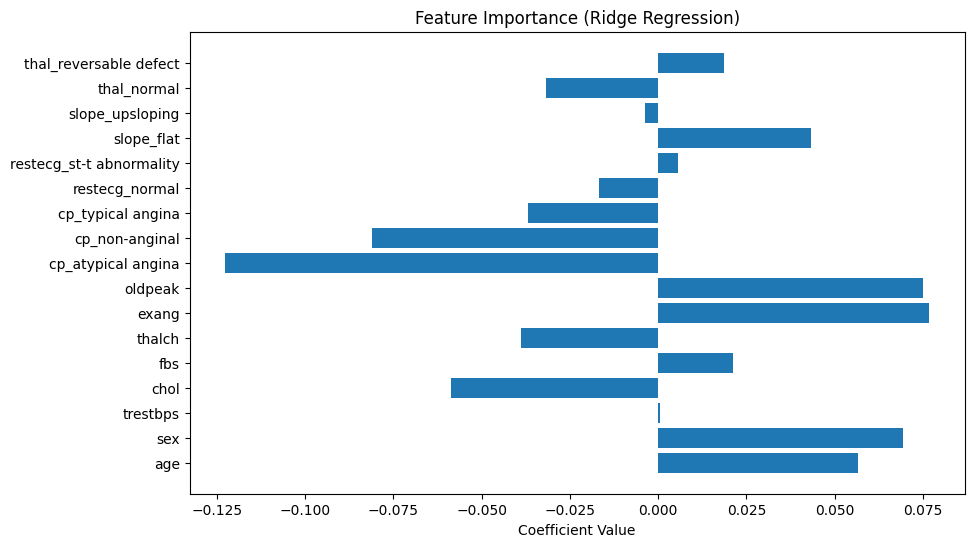

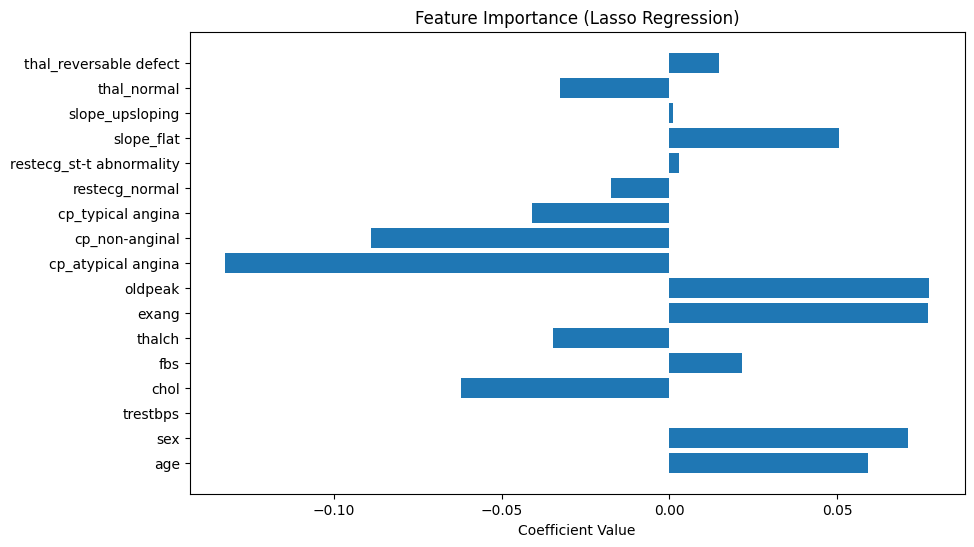

In [17]:
import matplotlib.pyplot as plt

# Get feature names after one-hot encoding
feature_names = X_train.columns

# Ridge coefficients
plt.figure(figsize=(10, 6))
plt.barh(feature_names, ridge_tuned.coef_)
plt.title("Feature Importance (Ridge Regression)")
plt.xlabel("Coefficient Value")
plt.show()

# Lasso coefficients
plt.figure(figsize=(10, 6))
plt.barh(feature_names, lasso_tuned.coef_)
plt.title("Feature Importance (Lasso Regression)")
plt.xlabel("Coefficient Value")
plt.show()

### 🧐 Feature Importance Analysis

The feature importance plots for **Ridge** and **Lasso Regression** provide valuable insights:

1. **Common Key Features:**
   - Features like `cp_atypical angina`, `age`, `sex`, and `thal_reversable defect` show strong influence on heart disease prediction.
   - Positive coefficients (right of zero) increase the likelihood of heart disease, while negative coefficients reduce it.

2. **Differences Between Ridge and Lasso:**
   - **Lasso** shrinks some coefficients closer to zero, effectively performing feature selection (e.g., `restecg_normal` and `slope_flat` are almost zero).
   - **Ridge** keeps all features but distributes the weights more smoothly.

3. **Interpretability:**
   - Coefficients closer to zero have less predictive power.
   - The large positive/negative coefficients indicate the most influential predictors.

**Key Insight:**  
- **Chest pain type (cp_atypical angina)**, **age**, and **sex** are among the strongest predictors of heart disease.
- Lasso’s ability to zero out unimportant features can help simplify the model without sacrificing performance.

## Conclusion – Deliverable 2: Regression Modeling and Evaluation

1. **Model Performance:**  
   - The tuned **Ridge Regression** and **Lasso Regression** models clearly outperformed Logistic Regression in R² and error metrics.  
   - Ridge showed slightly better RMSE, while Lasso is better for model simplicity.

2. **Cross-Validation:**  
   - Both tuned Ridge and Lasso achieved higher cross-validation R² scores than Logistic Regression, showing better generalization.

3. **Feature Insights:**  
   - **Chest pain type (cp_atypical angina)**, **age**, and **sex** emerged as the most important predictors of heart disease.  
   - Lasso zeroed out less impactful features, showing its advantage in feature selection.

**Key Takeaway:**  
- Ridge and Lasso (tuned) are the top-performing models for this dataset.  
- Use Lasso when you want a sparser, simpler model.  
- Ridge is more robust when retaining all features is preferred.

### 🔮 Next Steps (for Deliverable 3)
- Tune Logistic Regression for fairness in comparison.  
- Add metrics like precision, recall, and F1-score.  
- Consider ensemble models (e.g., Random Forest or XGBoost) for potential improvements.